# Exercício **B.6.15**

_Diagrama (Ogata): malha unitária negativa com compensador \(K\dfrac{T_1s+1}{T_2s+1}\) em série com a planta \(\dfrac{10}{s(s+1)}\)._

# Solução completa — **B.6.15**

> **Figura:** se precisar do desenho original, veja a **Figura 6.105** no livro.

## Enunciado

**Preciso determinar** **\(K\)**, **\(T_1\)** e **\(T_2\)** para o sistema em realimentação unitária negativa com

$$
G(s)=\Bigl[K\frac{T_1s+1}{T_2s+1}\Bigr]\cdot \frac{10}{s(s+1)}
$$

de forma que os **polos dominantes** em malha fechada tenham **\(\zeta=0{,}5\)** e **\(\omega_n=3\ \mathrm{rad/s}\)**.

---

## Passo 1 — Polos dominantes desejados

Para o par complexo padrão:

$$
s=-\zeta\omega_n \pm j\omega_n\sqrt{1-\zeta^2}
= -1{,}5 \pm j\frac{3\sqrt{3}}{2}
\approx -1{,}5 \pm j\,2{,}598.
$$

**Escrevo** o fator quadrático correspondente como

$$
s^2+2\zeta\omega_n s+\omega_n^2 = s^2+3s+9.
$$

---

## Passo 2 — Equação característica

**Parto de** \(H(s)=1\): \(1+G(s)=0\). Multiplicando pelo denominador,

$$
(T_2s+1)\,s(s+1)+10K(T_1s+1)=0.
$$

**Expandindo:**

$$
T_2s^3+(T_2+1)s^2+(1+10KT_1)s+10K=0.
$$

**Como** o sistema é de **3ª ordem**, ao fixar só o par complexo **ainda ficam dois parâmetros livres** (mais um polo real \(s=-p\)). Por isso imagino **uma família** de soluções \((K,T_1,T_2)\) até escolher um critério extra.

---

## Passo 3 — Casamento de coeficientes

**Busco** um polinômio proporcional a

$$
(s^2+3s+9)(s+p)=s^3+(p+3)s^2+(3p+9)s+9p.
$$

**Comparando** com \(T_2s^3+(T_2+1)s^2+(1+10KT_1)s+10K\), ao dividir por \(T_2\) (com \(T_2\neq 0\)):

$$
\frac{T_2+1}{T_2}=p+2\zeta\omega_n
\quad\Longrightarrow\quad
p=\frac{T_2+1}{T_2}-2\zeta\omega_n
=\frac{1}{T_2}-2\quad(\text{para }\zeta=0{,}5,\ \omega_n=3).
$$

Além disso

$$
10K = T_2\,\omega_n^2 p,
\qquad
1+10KT_1 = T_2\,(2\zeta\omega_n p+\omega_n^2).
$$

**Eliminando** \(p\) e \(K\), cheguei a \(T_1\) em função de \(T_2\).

---

## Passo 4 — Escolha usual do livro (cancelamento em \(s=-1\))

A planta tem polo em **\(s=-1\)**. Escolhendo **\(T_1=1\)** o zero do compensador fica em **\(-1/T_1=-1\)** e **cancela** esse polo na malha aberta.

**Substituindo** **\(T_1=1\)** nas equações **obtenho** a solução **única**

$$
T_2=\frac{1}{3},\qquad K=\frac{3}{10},\qquad T_1=1.
$$

Os polos em malha fechada ficam em **\(-1{,}5\pm j\,2{,}598\)** e **\(s=-1\)**.

**Sobre dominância:** observei que o polo real **\(-1\)** fica um pouco mais próximo do eixo imaginário que a parte real **\(-1{,}5\)** do par complexo; por um critério estrito de “modo mais lento”, esse polo interfere no transitório. **Se for necessário** garantir que o par complexo seja claramente dominante, **escolho** \(T_2\) menor **de forma que** **\(p>\zeta\omega_n=1{,}5\)** (polo real mais rápido); por exemplo, \(T_2=0{,}25\) segue essa linha.

---

## Passo 5 — Verificação e gráficos

**Para conferência**, avalio os polos e traço **resposta ao degrau** e **lugar das raízes** da malha aberta compensada com os ganhos obtidos.


 SOLUÇÃO A — cancelamento em s=-1 (T1=1)
 Especificação: ζ = 0.5,  ωn = 3 rad/s
 K  = 0.3
 T1 = 1
 T2 = 0.333333333333
 Terceiro polo (referência): s ≈ -1   (p = 1)
 Critério (terceiro polo mais rápido que o par dominante): precisa p > ζ·ωn = 1.5
 Neste caso p ≤ 1.5
 Polos em malha fechada:
   p1: -1.500000 -2.598076 j   |s|=3.000000
   p2: -1.500000 +2.598076 j   |s|=3.000000
   p3: -1.000000 +0.000000 j   |s|=1.000000
 Ganhos DC T(0) = 1
 SOLUÇÃO B — exemplo com T2=0.25 (ajuste de dominância)
 Especificação: ζ = 0.5,  ωn = 3 rad/s
 K  = 0.45
 T1 = 0.611111111111
 T2 = 0.25
 Terceiro polo (referência): s ≈ -2   (p = 2)
 Critério (terceiro polo mais rápido que o par dominante): precisa p > ζ·ωn = 1.5
 Neste caso p > 1.5
 Polos em malha fechada:
   p1: -2.000000 +0.000000 j   |s|=2.000000
   p2: -1.500000 -2.598076 j   |s|=3.000000
   p3: -1.500000 +2.598076 j   |s|=3.000000
 Ganhos DC T(0) = 1


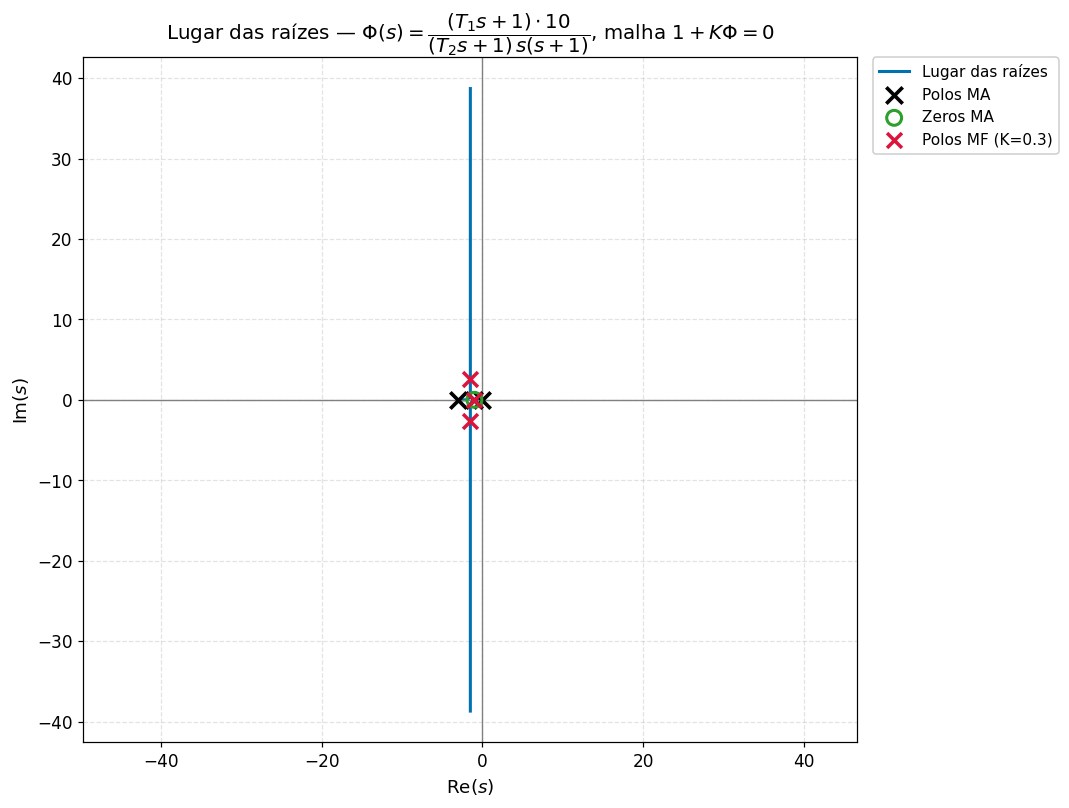

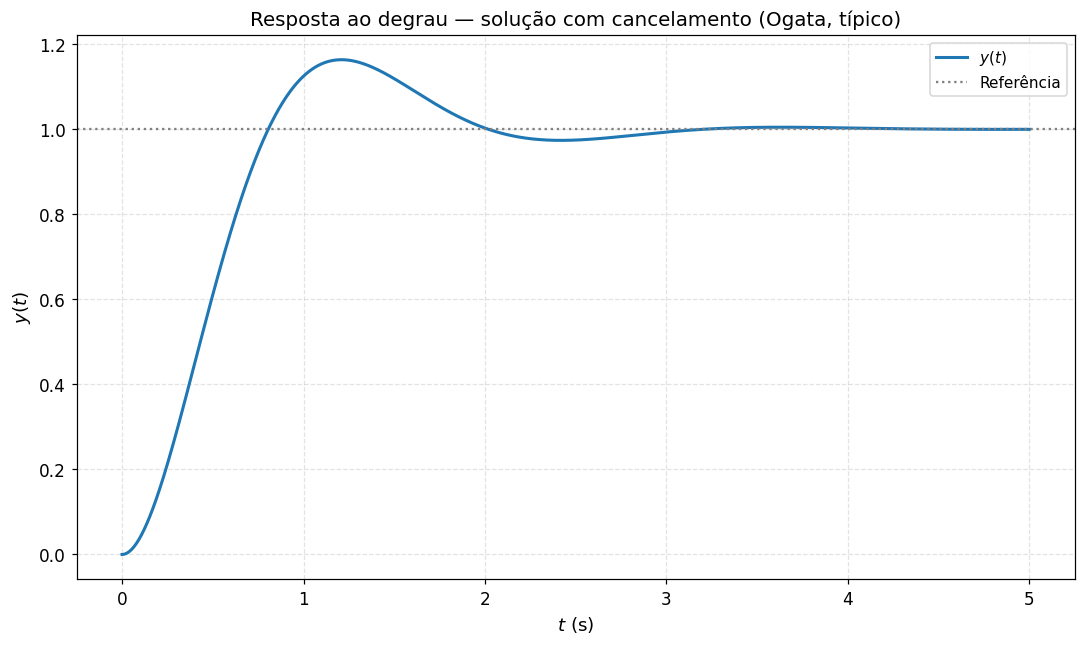

In [1]:
"""
Exercício B.6.15 — compensador K(T1 s + 1)/(T2 s + 1) + planta 10/(s(s+1)).
Verificação por `control` e gráficos (Malplotlib).
"""

from __future__ import annotations

import warnings

import control as ct
import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module=r"control\.rlocus",
)

plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 110,
        "font.size": 11,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.alpha": 0.35,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "legend.fontsize": 10,
    }
)


def planta() -> ct.TransferFunction:
    """Planta fixa do problema: 10/(s(s+1))."""
    return ct.tf([10.0], [1.0, 1.0, 0.0])


def compensador(k: float, t1: float, t2: float) -> ct.TransferFunction:
    """Compensador K·(T1 s + 1)/(T2 s + 1)."""
    return ct.tf(k * np.array([t1, 1.0]), np.array([t2, 1.0]))


def malha_aberta(k: float, t1: float, t2: float) -> ct.TransferFunction:
    """G(s) em malha aberta = compensador · planta."""
    return compensador(k, t1, t2) * planta()


def malha_fechada(k: float, t1: float, t2: float) -> ct.TransferFunction:
    """Realimentação unitária negativa."""
    return ct.feedback(malha_aberta(k, t1, t2), 1)


def polo_real_auxiliar(t2: float, zeta: float, omega_n: float) -> float:
    """
    Terceiro polo (real, em -p) quando o par dominante fixa s² + 2ζωn s + ωn².

    Da igualdade (T2+1)/T2 = p + 2ζωn, isolando p fica p = (T2+1)/T2 − 2ζωn.
    """
    zwn = 2.0 * zeta * omega_n
    return (t2 + 1.0) / t2 - zwn


def ganhos_a_partir_de_t2(zeta: float, omega_n: float, t2: float) -> tuple[float, float, float]:
    """
    Dado T2>0, calcula K e T1 para casar o polinômio desejado de grau 3.

    Usa p = (T2+1)/T2 − 2ζωn, 10K = T2·ωn²·p e 1+10K·T1 = T2·(2ζωn·p+ωn²).
    """
    if t2 <= 0:
        raise ValueError("T2 deve ser positivo.")
    p = polo_real_auxiliar(t2, zeta, omega_n)
    k = omega_n**2 * p * t2 / 10.0
    if abs(k) < 1e-15:
        raise ValueError("K calculado é ~0; escolha outro T2.")
    t1 = (t2 * (2.0 * zeta * omega_n * p + omega_n**2) - 1.0) / (10.0 * k)
    return float(k), float(t1), float(t2)


def solucao_cancelamento_polo(zeta: float, omega_n: float) -> tuple[float, float, float]:
    """
    Solução com T1=1 (zero em -1 cancelando o polo da planta em -1).

    Calculei fechando o sistema simbólico (T1=1); para ζ=0,5 e ωn=3: T2=1/3, K=3/10.
    """
    t1 = 1.0
    num = 1.0 + omega_n**2 - 2.0 * zeta * omega_n
    den = (
        2.0 * zeta * omega_n**3
        + 2.0 * zeta * omega_n
        - 4.0 * zeta**2 * omega_n**2
    )
    if abs(den) < 1e-15:
        raise ValueError("Combinação ζ–ωn singular para cancelamento com T1=1.")
    t2 = float(num / den)
    p = polo_real_auxiliar(t2, zeta, omega_n)
    k = omega_n**2 * p * t2 / 10.0
    return float(k), float(t1), float(t2)


def formatar_polos(polos: np.ndarray) -> None:
    """Lista ordenada com parte real / imaginária e |s|."""
    polos = np.sort_complex(polos)
    print(" Polos em malha fechada:")
    for i, p in enumerate(polos, start=1):
        print(
            f"   p{i}: {np.real(p):+.6f} {np.imag(p):+.6f} j   |s|={abs(p):.6f}"
        )


def relatorio_ganhos(
    titulo: str, zeta: float, omega_n: float, k: float, t1: float, t2: float
) -> None:
    """Texto consolidado no notebook/console."""
    sep = "=" * 72
    print(sep)
    print(f" {titulo}")
    print(sep)
    print(f" Especificação: ζ = {zeta:g},  ωn = {omega_n:g} rad/s")
    print(f" K  = {k:.12g}")
    print(f" T1 = {t1:.12g}")
    print(f" T2 = {t2:.12g}")
    p = polo_real_auxiliar(t2, zeta, omega_n)
    print(f" Terceiro polo (referência): s ≈ {-p:.12g}   (p = {p:.12g})")
    lim_dom = zeta * omega_n
    print(f" Critério (terceiro polo mais rápido que o par dominante): precisa p > ζ·ωn = {lim_dom:g}")
    print(f" Neste caso p {'>' if p > lim_dom else '≤'} {lim_dom:g}")
    sys_cl = malha_fechada(k, t1, t2)
    formatar_polos(ct.poles(sys_cl))
    print(f" Ganhos DC T(0) = {float(ct.dcgain(sys_cl)):.12g}")
    print(sep)


def vetor_ganhos_rl(k_ol: float, n: int = 3500) -> np.ndarray:
    """Vetor de ganhos para traçar o lugar das raízes de G0 = G/K (ganho externo 1)."""
    k_hi = max(50.0, float(k_ol) * 8.0)
    gain = np.linspace(1e-9, k_hi, n)
    return np.sort(np.unique(np.concatenate([gain, [float(k_ol)]])))


def plot_lugar_raizes_normalizado(sys_ol: ct.TransferFunction, k_usado: float) -> None:
    """
    Plota RL de Φ(s) = G(s)/K com ganho fictício K_var: malha 1 + K_var·Φ = 0.

    Assim o lugar corresponde ao ganho total K_var da malha aberta original.
    """
    fig, ax = plt.subplots(figsize=(10.5, 7.5))
    rl = ct.root_locus_map(sys_ol, gains=vetor_ganhos_rl(k_usado))
    loci = rl.loci
    for j in range(loci.shape[1]):
        ax.plot(
            np.real(loci[:, j]),
            np.imag(loci[:, j]),
            color="#0072B2",
            lw=2.0,
            label="Lugar das raízes" if j == 0 else None,
        )
    pp = rl.poles
    ax.scatter(
        np.real(pp),
        np.imag(pp),
        s=115,
        c="k",
        marker="x",
        linewidths=2.4,
        zorder=6,
        label="Polos MA",
    )
    zz = rl.zeros
    if len(zz):
        ax.scatter(
            np.real(zz),
            np.imag(zz),
            s=95,
            facecolors="none",
            edgecolors="#2ca02c",
            linewidths=2.0,
            zorder=6,
            label="Zeros MA",
        )
    ax.axhline(0.0, color="gray", lw=0.9)
    ax.axvline(0.0, color="gray", lw=0.9)
    polos_mf = ct.poles(ct.feedback(k_usado * sys_ol, 1))
    ax.scatter(
        np.real(polos_mf),
        np.imag(polos_mf),
        s=95,
        c="crimson",
        marker="x",
        linewidths=2.3,
        zorder=7,
        label=f"Polos MF (K={k_usado:g})",
    )
    ax.set_title(
        r"Lugar das raízes — $\Phi(s)=\dfrac{(T_1s+1)\cdot 10}{(T_2s+1)\,s(s+1)}$, "
        r"malha $1+K\Phi=0$"
    )
    ax.set_xlabel(r"$\mathrm{Re}(s)$")
    ax.set_ylabel(r"$\mathrm{Im}(s)$")
    ax.set_aspect("equal", adjustable="datalim")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0, framealpha=0.96)
    fig.subplots_adjust(left=0.07, right=0.74, top=0.92, bottom=0.09)


def plot_degrau(k: float, t1: float, t2: float, titulo: str) -> None:
    """Resposta ao degrau da malha fechada."""
    sys_cl = malha_fechada(k, t1, t2)
    t = np.linspace(0.0, 5.0, 3000)
    tout, yout = ct.step_response(sys_cl, t)
    fig, ax = plt.subplots()
    ax.plot(tout, yout, lw=2.0, label=r"$y(t)$")
    ax.axhline(1.0, color="gray", ls=":", lw=1.5, label="Referência")
    ax.set_title(titulo)
    ax.set_xlabel(r"$t$ (s)")
    ax.set_ylabel(r"$y(t)$")
    ax.legend(loc="best")
    plt.tight_layout()


# --- Parâmetros do enunciado ---
ZETA = 0.5
OMEGA_N = 3.0

# Solução clássica (cancelamento do polo em -1)
K0, T10, T20 = solucao_cancelamento_polo(ZETA, OMEGA_N)
relatorio_ganhos("SOLUÇÃO A — cancelamento em s=-1 (T1=1)", ZETA, OMEGA_N, K0, T10, T20)

# Família: exemplo com terceiro polo mais rápido (p > ζ·ωn)
T2_alt = 0.25
Ka, T1a, T2a = ganhos_a_partir_de_t2(ZETA, OMEGA_N, T2_alt)
relatorio_ganhos(
    f"SOLUÇÃO B — exemplo com T2={T2_alt:g} (ajuste de dominância)",
    ZETA,
    OMEGA_N,
    Ka,
    T1a,
    T2a,
)

# Gráficos para a solução A (a mais pedida nos gabaritos)
phi_a = malha_aberta(1.0, T10, T20)  # G/K
plot_lugar_raizes_normalizado(phi_a, K0)
plt.show()

plot_degrau(
    K0,
    T10,
    T20,
    "Resposta ao degrau — solução com cancelamento (Ogata, típico)",
)
plt.show()
